# 🤖 Project 2: Customer Churn Prediction
**Tools:** Python, Scikit-learn, Pandas, Seaborn  
**Objective:** Telecom customers ka churn predict karna using Machine Learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Dataset banana ──
np.random.seed(42)
n = 7200
df = pd.DataFrame({
    'CustomerID':    range(1, n+1),
    'Tenure':        np.random.randint(1, 72, n),
    'MonthlyCharges':np.random.uniform(20, 120, n).round(2),
    'TotalCharges':  np.random.uniform(100, 8000, n).round(2),
    'Contract':      np.random.choice(['Month-to-month','One year','Two year'], n, p=[0.5,0.3,0.2]),
    'InternetService':np.random.choice(['DSL','Fiber optic','No'], n),
    'SupportCalls':  np.random.randint(0, 10, n),
    'PaymentMethod': np.random.choice(['Electronic check','Mailed check','Bank transfer','Credit card'], n),
    'Churn':         np.random.choice([0,1], n, p=[0.74,0.26])
})

print("✅ Dataset ready!")
print(f"Shape: {df.shape}")
print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")
print("\nFirst 5 rows:")
df.head()

✅ Dataset ready!
Shape: (7200, 9)
Churn Rate: 25.9%

First 5 rows:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,SupportCalls,PaymentMethod,Churn
0,1,52,114.66,5982.66,One year,No,1,Bank transfer,0
1,2,15,92.63,6088.01,One year,No,5,Bank transfer,0
2,3,61,41.97,7982.91,Month-to-month,No,6,Bank transfer,1
3,4,21,64.91,7210.23,Month-to-month,No,1,Bank transfer,0
4,5,24,99.65,7415.89,Month-to-month,Fiber optic,9,Bank transfer,0


In [2]:
# ── Data Preprocessing ──
le = LabelEncoder()
df_enc = df.copy()
for col in ['Contract','InternetService','PaymentMethod']:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop(['CustomerID','Churn'], axis=1)
y = df_enc['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"Features     : {X.shape[1]}")
print("\n✅ Preprocessing complete!")

Training Set : 5760 records
Testing Set  : 1440 records
Features     : 7

✅ Preprocessing complete!


In [3]:
# ── Model Training & Comparison ──
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'KNN (k=5)':          KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = {'model': model, 'accuracy': acc, 'pred': y_pred}
    print(f"{name:22s} → Accuracy: {acc:.2f}%")

best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Best Model: {best_name} ({results[best_name]['accuracy']:.2f}%)")

Random Forest          → Accuracy: 73.47%
Logistic Regression    → Accuracy: 73.54%
Decision Tree          → Accuracy: 73.12%
KNN (k=5)              → Accuracy: 69.17%

🏆 Best Model: Logistic Regression (73.54%)


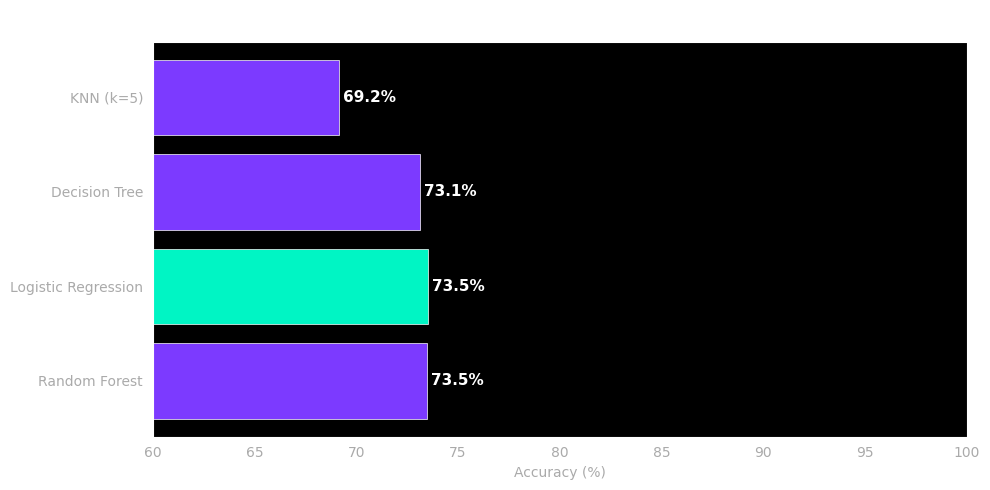

✅ Chart 1 done!


In [4]:
# ── CHART 1: Model Accuracy Comparison ──
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
colors = ['#00f5c4' if n == best_name else '#7c3aff' for n in names]

plt.figure(figsize=(10,5))
plt.style.use('dark_background')
bars = plt.barh(names, accs, color=colors, edgecolor='white', linewidth=0.5)
for bar, acc in zip(bars, accs):
    plt.text(acc + 0.2, bar.get_y() + bar.get_height()/2,
             f'{acc:.1f}%', va='center', fontsize=11, color='white', fontweight='bold')
plt.xlim(60, 100)
plt.xlabel('Accuracy (%)', color='#aaa')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', color='white', pad=12)
plt.xticks(color='#aaa'); plt.yticks(color='#aaa')
plt.tight_layout()
plt.savefig('p2_models.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("✅ Chart 1 done!")

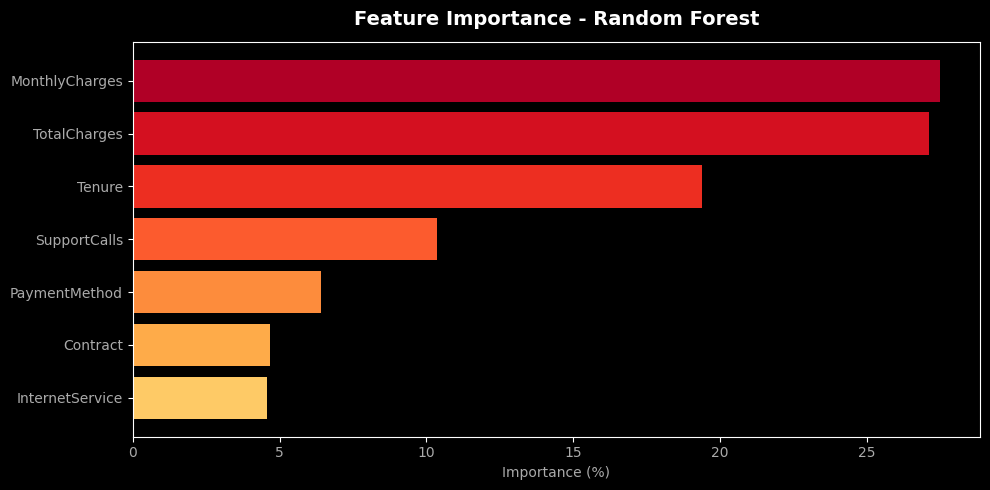

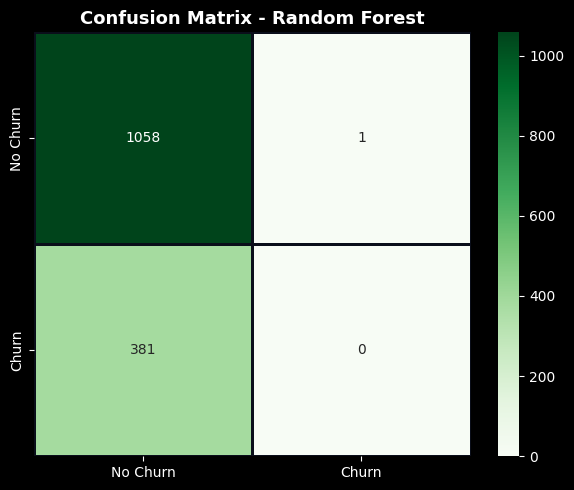


📊 Classification Report (Random Forest):
              precision    recall  f1-score   support

    No Churn       0.74      1.00      0.85      1059
       Churn       0.00      0.00      0.00       381

    accuracy                           0.73      1440
   macro avg       0.37      0.50      0.42      1440
weighted avg       0.54      0.73      0.62      1440



In [5]:
# ── CHART 2: Feature Importance ──
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10,5))
plt.style.use('dark_background')
colors_fi = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp)))
plt.barh(feat_imp.index, feat_imp.values * 100, color=colors_fi)
plt.xlabel('Importance (%)', color='#aaa')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold', color='white', pad=12)
plt.xticks(color='#aaa'); plt.yticks(color='#aaa')
plt.tight_layout()
plt.savefig('p2_features.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

# ── CHART 3: Confusion Matrix ──
cm = confusion_matrix(y_test, results['Random Forest']['pred'])
plt.figure(figsize=(6,5))
plt.style.use('dark_background')
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'],
            linewidths=1, linecolor='#0a0e1a')
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('p2_confusion.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

print("\n📊 Classification Report (Random Forest):")
print(classification_report(y_test, results['Random Forest']['pred'], target_names=['No Churn','Churn']))